# Camada Bronze - Ingestão dos dados RAW

## Objetivo
- Ler dados brutos no formato BrainVision (.vhdr/.eeg)
- Extrair sinais EEG utilizando MNE
- Integrar dados de sensores (ACC/GYRO)
- Padronizar nomes de colunas
- Adicionar metadados (subject, session, task_id, timestamp)
- Tratar sensores ausentes
- Converter tipos para otimização (float32)
- Salvar os dados em formato Parquet
- Criar tabela unificada com os dados raw

## Entrada
- data/raw/original/

## Saída
- data/bronze/full_table.parquet


# Importações

In [76]:
import os
import numpy as np
import pandas as pd
from mne.io import read_raw_brainvision

# Caminhos

In [77]:
RAW_PATH = "../data/raw/original"
BRONZE_PATH = "../data/bronze/full_table.parquet"

# Explorando sujeitos

In [78]:
subject = "001"
subject_path = os.path.join(RAW_PATH, subject)

os.listdir(subject_path)

['1211-003.eeg',
 '1211-003.vmrk',
 'LShank.csv',
 '1211-003.vhdr',
 'Arm.csv',
 'Waist.csv']

Como podemos ver o sujeito 1 apresenta arquivos nos formatos .eeg, .vmrk, .vhdr e csv's auxiliares, mas nem todos sujeitos possuem exatamente esses tipos de csv's e nem estão organizados da mesma forma:

In [79]:
subject = "004"
subject_path = os.path.join(RAW_PATH, subject)

os.listdir(subject_path)

['1219-007.eeg', '1219-007.vmrk', 'RShank.csv', 'Arm.csv', '1219-007.vhdr']

Isso faz com que tenhamos que padronizar esses dados brutos para a camada bronze que será a concatenação bruta deles.

# Lendo arquivos

In [80]:
vhdr_file = [f for f in os.listdir(subject_path) if f.endswith(".vhdr")][0]
vhdr_path = os.path.join(subject_path, vhdr_file)

raw = read_raw_brainvision(vhdr_path, preload=True, verbose=False)
eeg_data = raw.get_data().T

eeg_data.shape

/tmp/ipykernel_14037/4032978254.py:4: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = read_raw_brainvision(vhdr_path, preload=True, verbose=False)
/tmp/ipykernel_14037/4032978254.py:4: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (500.00 Hz, Nyquist limit) will be stored.
  raw = read_raw_brainvision(vhdr_path, preload=True, verbose=False)


(911320, 32)

os.listdir(subject_path) lista os arquivos dentro da pasta do sujeito pra poder em seguida filtrar aqueles que tem o formato .vhdr, pegando assim o primeiro (e único) [0]. Por fim unimos o nome do arquivo com o caminho da pasta com o .join.

A função read_raw_brainvision da biblioteca do MNE vai carregar os dados EEG através do endereço do .vhdr, já que esse arquivo é o manual de instruções para o computador ler nosso arquivo .eeg sem mostrar diversas mensagens no terminal (verbose=False).

Depois usando a função get_data conseguimos os dados .eeg em uma matriz numérica transposta para o formato (tempo, canais), assim os dados brutos lidos corretamente com separação de canais. 

o .shape nos dará a dimensão da matriz final, nesse caso ela teve 911320 pontos e 32 canais, como nosso último sujeito explorado foi o 004, temos que ele teve então 911320 (sendo 1000 Hz a taxa de amostragem isso daria uns 15 minutos de gravações) amostras de tempo e os padrões 32 canais de EEG.



In [81]:
df = pd.DataFrame(eeg_data)
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.000000e+00,0.000002,-0.000005,0.000003,-0.000005,0.000002,-0.000013,0.0,-0.000016,-0.000008,...,-0.000003,0.0,-0.000004,0.000006,-0.000009,0.000004,0.000005,0.000044,0.000005,0.000012
1,5.000000e-07,0.000003,-0.000005,0.000004,-0.000005,0.000002,-0.000013,0.0,-0.000015,-0.000007,...,-0.000003,0.0,-0.000005,0.000007,-0.000008,0.000005,0.000002,0.000054,0.000005,0.000013
2,1.500000e-06,0.000004,-0.000005,0.000005,-0.000005,0.000002,-0.000012,0.0,-0.000014,-0.000006,...,-0.000003,0.0,-0.000005,0.000008,-0.000007,0.000005,0.000002,0.000062,0.000005,0.000013
3,2.500000e-06,0.000005,-0.000005,0.000005,-0.000005,0.000002,-0.000012,0.0,-0.000013,-0.000005,...,-0.000003,0.0,-0.000005,0.000008,-0.000007,0.000006,0.000000,0.000063,0.000005,0.000013
4,3.500000e-06,0.000005,-0.000005,0.000005,-0.000005,0.000003,-0.000011,0.0,-0.000012,-0.000003,...,-0.000003,0.0,-0.000005,0.000009,-0.000006,0.000006,0.000000,0.000065,0.000005,0.000013
5,4.000000e-06,0.000006,-0.000005,0.000005,-0.000005,0.000003,-0.000010,0.0,-0.000010,-0.000002,...,-0.000003,0.0,-0.000005,0.000009,-0.000006,0.000006,0.000016,0.000080,0.000005,0.000013
6,4.500000e-06,0.000005,-0.000005,0.000005,-0.000005,0.000003,-0.000009,0.0,-0.000009,0.000000,...,-0.000003,0.0,-0.000005,0.000010,-0.000005,0.000007,0.000032,0.000090,0.000006,0.000013
7,4.500000e-06,0.000005,-0.000005,0.000004,-0.000004,0.000004,-0.000008,0.0,-0.000007,0.000002,...,-0.000003,0.0,-0.000005,0.000010,-0.000005,0.000007,0.000035,0.000089,0.000007,0.000013
8,5.000000e-06,0.000005,-0.000005,0.000004,-0.000004,0.000005,-0.000008,0.0,-0.000005,0.000003,...,-0.000003,0.0,-0.000005,0.000011,-0.000004,0.000007,0.000035,0.000084,0.000008,0.000013
9,5.000000e-06,0.000003,-0.000005,0.000004,-0.000003,0.000005,-0.000007,0.0,-0.000004,0.000005,...,-0.000002,0.0,-0.000003,0.000011,-0.000003,0.000007,0.000032,0.000083,0.000009,0.000013


Acima temos as 10 primeiras linhas do dataframe dos sinais EEG do sujeito 4.

Vamos agora tratar os csv's do sujeito 004:

In [82]:
def load_sensor(subject_path, sensor):
    file_path = os.path.join(subject_path, f"{sensor}.csv")
    
    if os.path.exists(file_path):
        data = pd.read_csv(file_path, header=None)
        data = data.iloc[:, 1:7]
        
        data.columns = [
            f"{sensor}_ACC_X",
            f"{sensor}_ACC_Y",
            f"{sensor}_ACC_Z",
            f"{sensor}_GYRO_X",
            f"{sensor}_GYRO_Y",
            f"{sensor}_GYRO_Z",
        ]
        
        return data
    else:
        return None

No código acima temos o endereço pro sensor sendo criado, em seguida temos a leitura do arquivo csv pegando apenas as colunas da posição 1 até a 6 (ignora a 0 que é o tempo). Depois colocamos nomes em cada uma das 6 colunas daquele sensor, 3 pro acelerômetro e 3 pro giroscópio, cada uma sendo um eixo. 

Verificando pro sensor arm do sujeito 4:

In [83]:
sensor_data = load_sensor(subject_path, "Arm")

if sensor_data is not None:
    print("Sucesso! O formato dos dados é:", sensor_data.shape)
    print(sensor_data.head()) # Mostra as primeiras 5 linhas com os nomes das colunas
else:
    print("Vish! O arquivo não foi encontrado no caminho especificado.")

Sucesso! O formato dos dados é: (224654, 6)
   Arm_ACC_X  Arm_ACC_Y  Arm_ACC_Z  Arm_GYRO_X  Arm_GYRO_Y  Arm_GYRO_Z
0        151       1164       7647          52          50           6
1        145       1153       7638          51          46           7
2        145       1153       7638          51          46           7
3        145       1153       7638          51          46           7
4        145       1153       7638          51          46           7


Se fossemos tentar achar pro sensor LShank, não iríamos encontrar nada pois o sujeito 4 não usou esse sensor: 

In [84]:
sensor_data = load_sensor(subject_path, "LShank")

if sensor_data is not None:
    print("Sucesso! O formato dos dados é:", sensor_data.shape)
    print(sensor_data.head()) # Mostra as primeiras 5 linhas com os nomes das colunas
else:
    print("Vish! O arquivo não foi encontrado no caminho especificado.")

Vish! O arquivo não foi encontrado no caminho especificado.


Agora, como podemos perceber acima, o número de medições é diferente pro mesmo sujeito: sensores-> (224654, 6), eeg-> (911320, 32). Logo temos que percorrer por todos os tipos de sensores que um sujeito pode ter, usar o load_sensor que fizemos e ir pegando o menor número de medições dentre os sensores pra cortar as linhas extras e se um determinado sensor não existir pra um sujeito ele vai ter suas colunas preenchidas com NaN, depois, concatenamos tudo isso em uma grande tabela. implementamos isso da seguinte forma:

In [85]:
sensors = ["LShank", "RShank", "Waist", "Arm"]

for sensor in sensors:
    sensor_df = load_sensor(subject_path, sensor)
    
    if sensor_df is not None:
        min_len = min(len(df), len(sensor_df))
        df = df.iloc[:min_len]
        sensor_df = sensor_df.iloc[:min_len]
        
        df = pd.concat([df, sensor_df], axis=1)
    else:
        for col in [
            f"{sensor}_ACC_X",
            f"{sensor}_ACC_Y",
            f"{sensor}_ACC_Z",
            f"{sensor}_GYRO_X",
            f"{sensor}_GYRO_Y",
            f"{sensor}_GYRO_Z",
        ]:
            df[col] = np.nan

Obtemos então a seguinte tabela de sinais para o sujeito 004:

In [86]:
df["subject"] = subject
print("Concatenação foi um sucesso! O formato dos dados é:", df.shape)
df.head()


Concatenação foi um sucesso! O formato dos dados é: (224654, 57)


,0,1,2,3,4,5,6,7,8,9,...,Waist_GYRO_X,Waist_GYRO_Y,Waist_GYRO_Z,Arm_ACC_X,Arm_ACC_Y,Arm_ACC_Z,Arm_GYRO_X,Arm_GYRO_Y,Arm_GYRO_Z,subject
0,0.000000e+00,0.000002,-0.000005,0.000003,-0.000005,0.000002,-0.000013,0.0,-0.000016,-0.000008,...,NaN,NaN,NaN,151,1164,7647,52,50,6,004
1,5.000000e-07,0.000003,-0.000005,0.000004,-0.000005,0.000002,-0.000013,0.0,-0.000015,-0.000007,...,NaN,NaN,NaN,145,1153,7638,51,46,7,004
2,1.500000e-06,0.000004,-0.000005,0.000005,-0.000005,0.000002,-0.000012,0.0,-0.000014,-0.000006,...,NaN,NaN,NaN,145,1153,7638,51,46,7,004
3,2.500000e-06,0.000005,-0.000005,0.000005,-0.000005,0.000002,-0.000012,0.0,-0.000013,-0.000005,...,NaN,NaN,NaN,145,1153,7638,51,46,7,004
4,3.500000e-06,0.000005,-0.000005,0.000005,-0.000005,0.000003,-0.000011,0.0,-0.000012,-0.000003,...,NaN,NaN,NaN,145,1153,7638,51,46,7,004


# Organizando os sujeitos

Mas ainda precisamos fazer isso para todos os sujeitos.

In [87]:
import os
import numpy as np
import pandas as pd
from mne.io import read_raw_brainvision

RAW_PATH = "../data/raw/"
OUTPUT_FILE = "../data/bronze/full_table.parquet"

ZERO_EPS = 1e-8
MISSING_THRESHOLD = 0.95

# =========================
# COLUNAS PADRÃO
# =========================

eeg_tags = [
    'EEG-FP1','EEG-FP2','EEG-F3','EEG-F4','EEG-C3','EEG-C4',
    'EEG-P3','EEG-P4','EEG-O1','EEG-O2','EEG-F7','EEG-F8',
    'EEG-P7','EEG-P8','EEG-FZ','EEG-CZ','EEG-PZ',
    'EEG-FC1','EEG-FC2','EEG-CP1','EEG-CP2',
    'EEG-FC5','EEG-FC6','EEG-CP5','EEG-CP6'
]

bio_standard = ["EMG-RTA", "EMG-LTA", "EMG-RGS", "IO", "ECG"]

acc_tags = [
    'LShank-ACCX','LShank-ACCY','LShank-ACCZ','LShank-GYRO-X','LShank-GYRO-Y','LShank-GYRO-Z','LShank-NC/SC',
    'RShank-ACCX','RShank-ACCY','RShank-ACCZ','RShank-GYRO-X','RShank-GYRO-Y','RShank-GYRO-Z','RShank-NC/SC',
    'Waist-ACCX','Waist-ACCY','Waist-ACCZ','Waist-GYRO-X','Waist-GYRO-Y','Waist-GYRO-Z','Waist-NC/SC',
    'Arm-ACCX','Arm-ACCY','Arm-ACCZ','Arm-GYRO-X','Arm-GYRO-Y','Arm-GYRO-Z','Arm-NC/SC'
]

ALL_COLUMNS = (
    ["timestamp", "patient_id", "task_id", "session"] +
    eeg_tags + bio_standard + acc_tags + ["label"]
)

# =========================
# TIPOS GARANTIDOS
# =========================

DTYPES = {col: "float32" for col in (eeg_tags + bio_standard + acc_tags + ["label"])}
DTYPES.update({
    "timestamp": "str",
    "patient_id": "str",
    "task_id": "str",
    "session": "str"
})

# =========================
# BIOSINAL
# =========================

BIO_MAPPING = {
    "001": ["EMG-RTA", "EMG-LTA", "IO", "ECG", "EMG-RGS"],
    "002": ["EMG-RTA", "EMG-LTA", "ECG", "EMG-RGS"],
    "003": ["EMG-LTA", "EMG-RTA", "ECG", "EMG-RGS"],
    "004": ["EMG-LTA", "EMG-RTA", "ECG", "EMG-RGS"],
    "005": ["EMG-LTA", "EMG-RTA", "ECG", "EMG-RGS"],
    "006": ["EMG-RTA", "EMG-LTA", "ECG", "EMG-RGS"],
    "007": ["EMG-RTA", "EMG-LTA", "ECG", "EMG-RGS"],
    "008-1": ["EMG-RTA", "EMG-LTA", "ECG", "EMG-RGS"],
    "008-2": ["EMG-RTA", "EMG-RGS", "ECG", "EMG-LTA"],
    "009": ["EMG-LTA", "EMG-RTA", "EMG-RGS", "ECG"],
    "010": ["EMG-LTA", "EMG-RTA", "ECG", "EMG-RGS"],
    "011": ["EMG-LTA", "EMG-RTA", "ECG", "EMG-RGS"],
    "012": ["EMG-LTA", "EMG-RTA", "ECG", "EMG-RGS"],
}

# =========================
# FUNÇÕES
# =========================

def is_missing_channel(values):
    zero_ratio = np.mean(np.abs(values) < ZERO_EPS)
    return zero_ratio > MISSING_THRESHOLD


def load_sensor(path, sensor):
    file_path = os.path.join(path, f"{sensor}.csv")

    if os.path.exists(file_path):
        data = pd.read_csv(file_path, header=None)
        data = data.iloc[:, 1:8]

        data.columns = [
            f"{sensor}-ACCX",
            f"{sensor}-ACCY",
            f"{sensor}-ACCZ",
            f"{sensor}-GYRO-X",
            f"{sensor}-GYRO-Y",
            f"{sensor}-GYRO-Z",
            f"{sensor}-NC/SC",
        ]
        return data.astype("float32")
    return None


def fix_bio_channels(df, subject_id):
    bio_cols = [c for c in df.columns if any(x in c for x in ["EMG", "ECG", "IO"])]

    for col in bio_standard:
        df[col] = np.nan

    if subject_id in BIO_MAPPING:
        mapping = BIO_MAPPING[subject_id]

        for i, name in enumerate(mapping):
            if i < len(bio_cols):
                df[name] = df[bio_cols[i]]

    df = df.drop(columns=bio_cols, errors="ignore")
    return df

# =========================
# CORREÇÃO EEG
# =========================
def fix_eeg_names(df):
    rename_map = {
        "FP1": "EEG-FP1", "FP2": "EEG-FP2",
        "F3": "EEG-F3", "F4": "EEG-F4",
        "C3": "EEG-C3", "C4": "EEG-C4",
        "P3": "EEG-P3", "P4": "EEG-P4",
        "O1": "EEG-O1", "O2": "EEG-O2",
        "F7": "EEG-F7", "F8": "EEG-F8",
        "P7": "EEG-P7", "P8": "EEG-P8",
        "FZ": "EEG-FZ", "CZ": "EEG-CZ", "PZ": "EEG-PZ",
        "FC1": "EEG-FC1", "FC2": "EEG-FC2",
        "CP1": "EEG-CP1", "CP2": "EEG-CP2",
        "FC5": "EEG-FC5", "FC6": "EEG-FC6",
        "CP5": "EEG-CP5", "CP6": "EEG-CP6",
    }
    return df.rename(columns=rename_map)


# =========================
# NORMALIZA ID
# =========================
def normalize_subject_id(subject_id):
    return subject_id.replace("original-", "")


def enforce_schema(df):
    # garantir todas colunas
    for col in ALL_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan

    df = df[ALL_COLUMNS]

    # tipos
    for col, dtype in DTYPES.items():
        if dtype == "float32":
            df[col] = df[col].astype("float32")
        else:
            df[col] = df[col].astype("string")

    return df


# =========================
# PIPELINE
# =========================

all_data = []

for subject in sorted(os.listdir(RAW_PATH)):
    subject_path = os.path.join(RAW_PATH, subject)

    if not os.path.isdir(subject_path):
        continue

    subfolders = [
        f for f in os.listdir(subject_path)
        if os.path.isdir(os.path.join(subject_path, f))
    ]

    if len(subfolders) == 0:
        paths = [(subject, subject_path)]
    else:
        paths = [(f"{subject}-{sub}", os.path.join(subject_path, sub)) for sub in subfolders]

    for subject_id, path in paths:
        subject_id = normalize_subject_id(subject_id)
        vhdr_files = [f for f in os.listdir(path) if f.endswith(".vhdr")]
        if not vhdr_files:
            continue

        raw = read_raw_brainvision(os.path.join(path, vhdr_files[0]), preload=True, verbose=False)

        df = pd.DataFrame(raw.get_data().T, columns=raw.ch_names)
        df = fix_eeg_names(df)
        
        # timestamp garantido como string
        timestamp = np.arange(len(df)) / raw.info["sfreq"]
        df["timestamp"] = timestamp.astype(str)

        # biosinais
        df = fix_bio_channels(df, subject_id)

        # sensores
        for sensor in ["LShank", "RShank", "Waist", "Arm"]:
            sensor_df = load_sensor(path, sensor)

            if sensor_df is not None:
                min_len = min(len(df), len(sensor_df))
                df = df.iloc[:min_len]
                sensor_df = sensor_df.iloc[:min_len]
                df = pd.concat([df, sensor_df], axis=1)
            else:
                for col in [c for c in acc_tags if c.startswith(sensor)]:
                    df[col] = np.nan

        # sensores mortos
        for col in acc_tags:
            if col in df.columns:
                if is_missing_channel(df[col].values):
                    df[col] = np.nan

        # metadados
        df["patient_id"] = subject_id
        if "-" in subject_id:
            df["session"] = subject_id.split("-")[1]
            df["patient_id"] = subject_id.split("-")[0]
        else:
            df["session"] = "1"
        df["task_id"] = "unknown"
        df["label"] = np.nan

        # schema final
        df = enforce_schema(df)
        all_data.append(df)

# concat final
final_df = pd.concat(all_data, ignore_index=True)
final_df = final_df.sort_values(by=["patient_id", "timestamp"])

os.makedirs(os.path.dirname(OUTPUT_FILE), exist_ok=True)
final_df.to_parquet(OUTPUT_FILE, index=False)

print("Dataset padronizado único dos dados raw criado com sucesso!")

/tmp/ipykernel_14037/2437907087.py:189: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = read_raw_brainvision(os.path.join(path, vhdr_files[0]), preload=True, verbose=False)
/tmp/ipykernel_14037/2437907087.py:189: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (500.00 Hz, Nyquist limit) will be stored.
  raw = read_raw_brainvision(os.path.join(path, vhdr_files[0]), preload=True, verbose=False)
/tmp/ipykernel_14037/2437907087.py:189: RuntimeWarning: Online software filter detected. Using software filter settings and ignoring hardware values
  raw = read_raw_brainvision(os.path.join(path, vhdr_files[0]), preload=True, verbose=False)
/tmp/ipykernel_14037/2437907087.py:189: RuntimeWarning: Channels contain different lowpass filters. Highest (weakest) filter setting (500.00 Hz, Nyquist limit) will be stored.
  raw = read_raw_brainvision(os.path.join(path, vhdr_files[0]), preload

Dataset padronizado único dos dados raw criado com sucesso!


# Pipeline de Construção do Dataset Multimodal

O código acima tem como objetivo transformar dados brutos de múltiplos sensores (EEG, EMG, ECG e sensores inerciais) em uma única tabela estruturada e padronizada, pronta para análise ou uso em modelos de machine learning.

---

## Problema Principal

O dataset original possui várias inconsistências:

* A ordem dos canais de biosinais (EMG, ECG, IO) muda entre pacientes
* Nem todos os pacientes possuem todos os sensores
* O paciente 008 possui duas sessões separadas (008-1 e 008-2)
* Os dados vêm de diferentes fontes (EEG em `.vhdr` e sensores em `.csv`)

---

## O que o código faz

### 1. Leitura dos dados EEG

Os dados são carregados a partir de arquivos `.vhdr` usando a biblioteca MNE:

* Cada linha representa um instante no tempo
* Cada coluna representa um canal (EEG ou biosinal)

Também é criado um `timestamp` baseado na frequência de amostragem.

---

### 2. Correção dos biosinais (EMG, ECG, IO)

Esse é o ponto mais chato do nosso dataset.

Cada paciente tem uma ordem diferente desses sinais. Então o código:

* Consulta um mapeamento baseado no ID do paciente
* Reorganiza os sinais corretamente
* Garante que todos tenham as mesmas colunas:

  * EMG-RTA
  * EMG-LTA
  * EMG-RGS
  * IO
  * ECG

Se algum sinal não existir, ele é preenchido com `NaN`.

---

### 3. Integração dos sensores inerciais

Para cada sensor (LShank, RShank, Waist, Arm):

* Se o arquivo CSV existe → ele é carregado
* Se não existe → colunas são criadas com `NaN`

Isso garante consistência estrutural entre todos os pacientes.

---

### 4. Tratamento de sensores "mortos"

Alguns sensores podem existir, mas conter apenas zeros.

O código detecta isso e substitui por `NaN`, evitando dados inválidos.

---

### 5. Tratamento especial do paciente 008

O paciente 008 possui duas sessões:

* 008-1
* 008-2

O código trata cada uma como um paciente independente, evitando mistura de dados.

---

### 6. Padronização final

Antes de salvar:

* Todas as colunas esperadas são garantidas
* A ordem das colunas é fixa
* Dados ausentes são preenchidos com `NaN`

---

### 7. Geração da tabelona

Todos os pacientes são concatenados em um único DataFrame:

```
timestamp | patient_id | task_id | session | EEG... | EMG... | ACC... | label
```

Essa tabela é então salva em formato Parquet.

---

Obtemos então um dataset:

* Padronizado
* Pronto para análise
* Robusto contra dados faltantes
* Consistente entre pacientes

---


# Resultados

Podemos observar então os primeiros resultados e outros dados gerais das amostras dessa tabela:

In [88]:
import pandas as pd

FILE_PATH = "../data/bronze/full_table.parquet"

df = pd.read_parquet(FILE_PATH)

print("\n" + "="*60)
print("VISÃO GERAL DO DATASET")
print("="*60)

print(f"\nShape (linhas, colunas): {df.shape}")
print(f"Total de colunas: {len(df.columns)}")

# =========================
# COLUNAS ORGANIZADAS
# =========================
print("\n" + "="*60)
print("COLUNAS DO DATASET")
print("="*60)

for i, col in enumerate(df.columns):
    print(f"{i:02d} | {col}")

# =========================
# HEAD FORMATADO
# =========================
print("\n" + "="*60)
print("PRIMEIRAS LINHAS (HEAD)")
print("="*60)

print(df.head().to_string())

# =========================
# AMOSTRA ALEATÓRIA
# =========================
print("\n" + "="*60)
print("AMOSTRA ALEATÓRIA")
print("="*60)

print(df.sample(5).to_string())

# =========================
# TIPOS DE DADOS
# =========================
print("\n" + "="*60)
print("TIPOS DE DADOS")
print("="*60)

print(df.dtypes)

# =========================
# VALORES NULOS
# =========================
print("\n" + "="*60)
print("VALORES NULOS (TOP 20)")
print("="*60)

print(df.isna().sum().sort_values(ascending=False).head(20))

# =========================
# CHECAGEM DE PADRÃO
# =========================
print("\n" + "="*60)
print("VALIDAÇÃO RÁPIDA")
print("="*60)

print("Timestamp é string:", df["timestamp"].dtype)
print("Patient_id é string:", df["patient_id"].dtype)
print("Session tem valores nulos:", df["session"].isna().sum())
print("Label dtype:", df["label"].dtype)


VISÃO GERAL DO DATASET

Shape (linhas, colunas): (3504894, 63)
Total de colunas: 63

COLUNAS DO DATASET
00 | timestamp
01 | patient_id
02 | task_id
03 | session
04 | EEG-FP1
05 | EEG-FP2
06 | EEG-F3
07 | EEG-F4
08 | EEG-C3
09 | EEG-C4
10 | EEG-P3
11 | EEG-P4
12 | EEG-O1
13 | EEG-O2
14 | EEG-F7
15 | EEG-F8
16 | EEG-P7
17 | EEG-P8
18 | EEG-FZ
19 | EEG-CZ
20 | EEG-PZ
21 | EEG-FC1
22 | EEG-FC2
23 | EEG-CP1
24 | EEG-CP2
25 | EEG-FC5
26 | EEG-FC6
27 | EEG-CP5
28 | EEG-CP6
29 | EMG-RTA
30 | EMG-LTA
31 | EMG-RGS
32 | IO
33 | ECG
34 | LShank-ACCX
35 | LShank-ACCY
36 | LShank-ACCZ
37 | LShank-GYRO-X
38 | LShank-GYRO-Y
39 | LShank-GYRO-Z
40 | LShank-NC/SC
41 | RShank-ACCX
42 | RShank-ACCY
43 | RShank-ACCZ
44 | RShank-GYRO-X
45 | RShank-GYRO-Y
46 | RShank-GYRO-Z
47 | RShank-NC/SC
48 | Waist-ACCX
49 | Waist-ACCY
50 | Waist-ACCZ
51 | Waist-GYRO-X
52 | Waist-GYRO-Y
53 | Waist-GYRO-Z
54 | Waist-NC/SC
55 | Arm-ACCX
56 | Arm-ACCY
57 | Arm-ACCZ
58 | Arm-GYRO-X
59 | Arm-GYRO-Y
60 | Arm-GYRO-Z
61 | Arm-NC

# Análise Estrutural do Dataset Bruto

## Visão Geral

Nosso dataset consolidado apresenta as seguintes características:

- **Total de linhas:** ~3.5 milhões  
- **Total de colunas:** 63  
- **Tipos de dados predominantes:** `float32` (biosinais) e `string` (metadados)

A estrutura foi organizada de forma tabular, onde:

- Cada linha representa um instante temporal (`timestamp`)
- Cada coluna representa um canal de sinal ou metadado

---

## Estrutura dos Dados

O dataset é composto por múltiplas fontes de sinais:

### 🔹 EEG (Eletroencefalograma)
Canais como:
- `EEG-FP1`, `EEG-FP2`, `EEG-F3`, `EEG-F4`
- `EEG-C3`, `EEG-C4`, `EEG-P3`, `EEG-P4`
- `EEG-O1`, `EEG-O2`, etc.

Esses sinais representam a atividade elétrica cerebral ao longo do tempo.

---

### 🔹 EMG / ECG / IO
- `EMG-RTA`, `EMG-LTA`, `EMG-RGS`
- `ECG`
- `IO`

Esses canais complementam o EEG com informações musculares e cardíacas.

---

### 🔹 Sensores Inerciais (IMU)

Cada sensor possui 7 canais:

- Acelerômetro: `ACCX`, `ACCY`, `ACCZ`
- Giroscópio: `GYRO-X`, `GYRO-Y`, `GYRO-Z`
- Canal adicional: `NC/SC`

Sensores disponíveis:

- `LShank` (perna esquerda)
- `RShank` (perna direita)
- `Waist` (cintura)
- `Arm` (braço)

---

## Heterogeneidade dos Dados

Nosso dataset é **multimodal e heterogêneo**, o que implica:

- Nem todos os pacientes possuem todos os sensores  
- Nem todos os canais estão presentes em todos os registros  
- Isso resulta em **valores ausentes (NaN)**

Essa característica é comum em datasets médicos reais e não representa erro.

---

## Valores Ausentes (NaNs)

A presença de valores nulos ocorre principalmente por:

### Sensores não disponíveis
Exemplo:
- Um paciente pode ter `RShank` mas não `Waist`
- As colunas ausentes são preenchidas com `NaN`

---

### Canais não presentes no dataset

Alguns canais esperados em montagens EEG clássicas, como:

- `EEG-FZ`
- `EEG-CZ`
- `EEG-PZ`

não fazem parte do dataset original.  

Essas colunas aparecem totalmente preenchidas com `NaN`, o que indica que:

> Esses sinais não foram coletados durante o experimento.

---

### Biosinais parciais

Canais como `ECG`, `IO` e alguns `EMG` aparecem apenas em parte dos pacientes, resultando em grande quantidade de valores ausentes.

---

## Labels e Task ID

### Label

A coluna `label` encontra-se **totalmente vazia (NaN)** neste dataset.

Isso ocorre porque:

- A rotulação é uma tarefa custosa e especializada  
- Os responsáveis pelo dataset já realizaram esse processo previamente  

Os labels estão disponíveis em:

- Forma bruta: `data/raw/filtered.txt`  
- Forma estruturada: `data/bronze/filtered_parquet`  

Portanto:

> Este dataset representa os dados **em estado bruto (raw)**, ainda sem anotação.

---

### Task ID

A coluna `task_id` aparece como:

```unknown```

Isso é esperado, pois:

Os dados ainda não foram associados às tarefas experimentais
A divisão por tarefas já está presente no dataset filtrado

Assim:

O task_id será corretamente preenchido ao integrar os dados com o dataset filtrado (filtered_parquet)

## Metadados

### patient_id

Identifica o paciente ao qual cada amostra pertence.

Exemplo:

001, 002, ..., 012

### session

- Representa a sessão de coleta do paciente.

- Para a maioria dos pacientes:

- session = 1

- Para casos específicos, como o patient_id = 008:

session = 1 ou 2


### timestamp

- Representa o tempo da amostra
- Está em formato string
- Derivado da frequência de amostragem do sinal

Cada linha corresponde a um instante contínuo no tempo.

## Padronização do Dataset

Nosso dataset foi estruturado para garantir:

- Mesmo número de colunas para todos os registros
- Organização consistente entre pacientes
- Compatibilidade com pipelines de Machine Learning

Isso implica que:

- Colunas ausentes são mantidas e preenchidas com NaN
- O schema permanece fixo, mesmo com variações entre sujeitos

## Interpretação Geral

Este dataset representa um cenário realista de dados biomédicos:

- Alta dimensionalidade
- Multiplas fontes de sinal
- Presença significativa de dados ausentes
- Separação entre dados brutos e dados filtrados

A estrutura atual permite:

- Análises exploratórias robustas
- Integração futura com labels
- Preparação para modelos de aprendizado de máquina


# Estatísticas e Gráficos do Dataset Bruto

## 1. Estatísticas Descritivas 

In [101]:
print("="*60)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*60)

desc = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(desc.T)

ESTATÍSTICAS DESCRITIVAS
                   count          mean          std           min  \
EEG-FP1        3504894.0  2.631304e-08     0.000038     -0.000420   
EEG-FP2        3504894.0 -1.076624e-08     0.000026     -0.000188   
EEG-F3         3504894.0  1.788489e-09     0.000015     -0.000321   
EEG-F4         3504894.0  3.636768e-09     0.000011     -0.000133   
EEG-C3         3504894.0  6.293490e-09     0.000008     -0.000098   
EEG-C4         3504894.0  3.993550e-09     0.000009     -0.000091   
EEG-P3         3504894.0  7.977279e-09     0.000012     -0.000129   
EEG-P4         3504894.0  8.683497e-10     0.000011     -0.000100   
EEG-O1         3504894.0  2.396244e-08     0.000038     -0.001297   
EEG-O2         3504894.0  2.491701e-08     0.000040     -0.001314   
EEG-F7         3504894.0 -3.726965e-09     0.000030     -0.000442   
EEG-F8         3504894.0  1.032271e-08     0.000028     -0.000324   
EEG-P7         3504894.0  1.823524e-08     0.000022     -0.000296   
EEG-P8   

## 2. Distribuição (Histogramas)

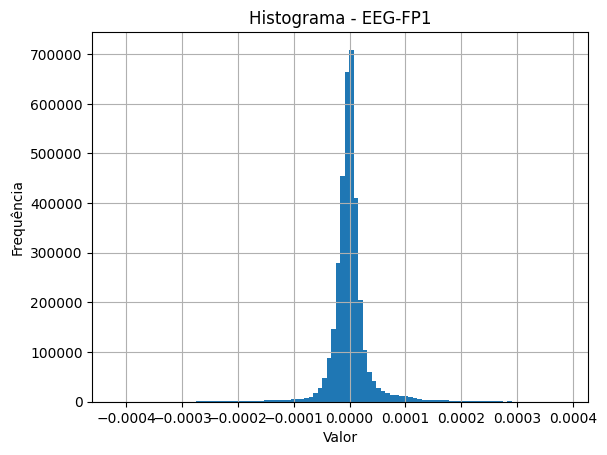

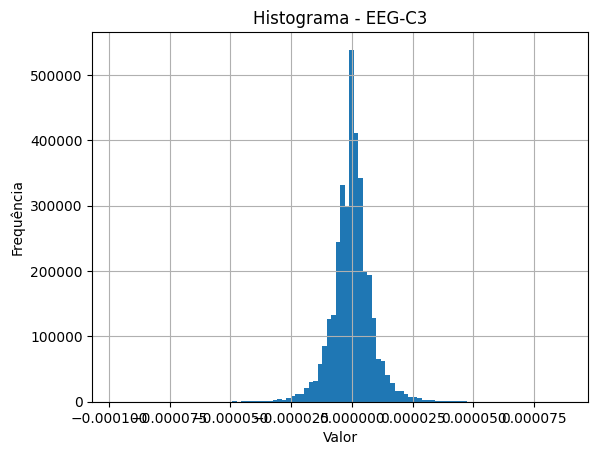

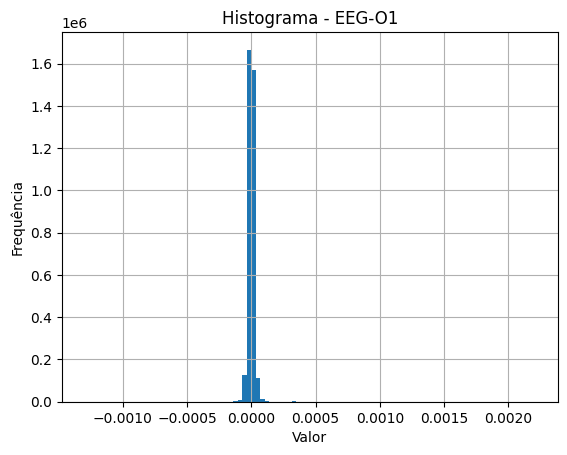

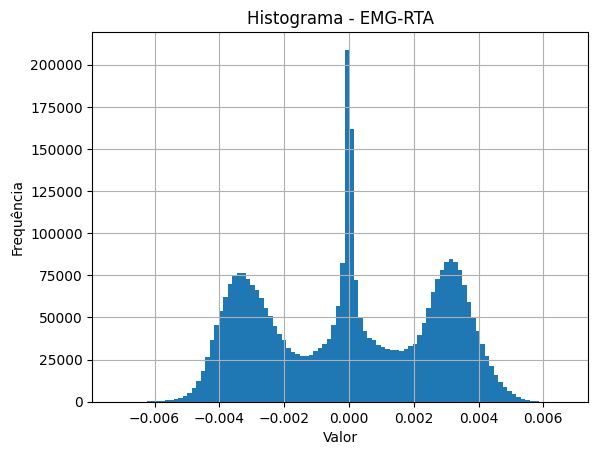

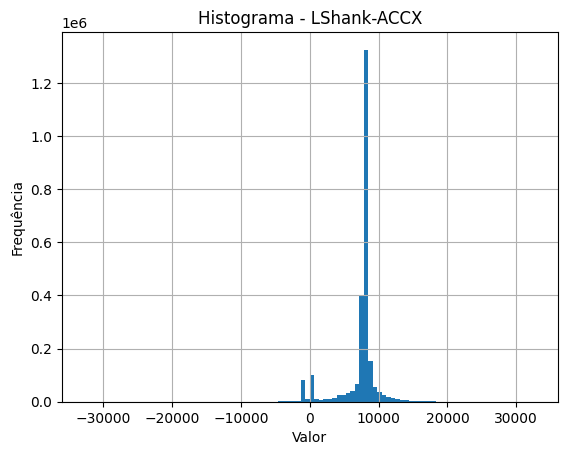

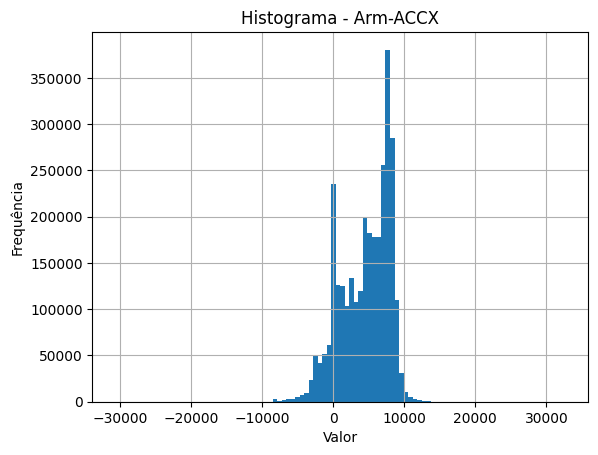

In [102]:
import matplotlib.pyplot as plt

cols_to_plot = [
    "EEG-FP1", "EEG-C3", "EEG-O1",
    "EMG-RTA",
    "LShank-ACCX",
    "Arm-ACCX"
]

for col in cols_to_plot:
    if col in df.columns:
        plt.figure()
        df[col].dropna().hist(bins=100)
        plt.title(f"Histograma - {col}")
        plt.xlabel("Valor")
        plt.ylabel("Frequência")
        plt.show()

## 3. Boxplot (Detecção de Outliers)

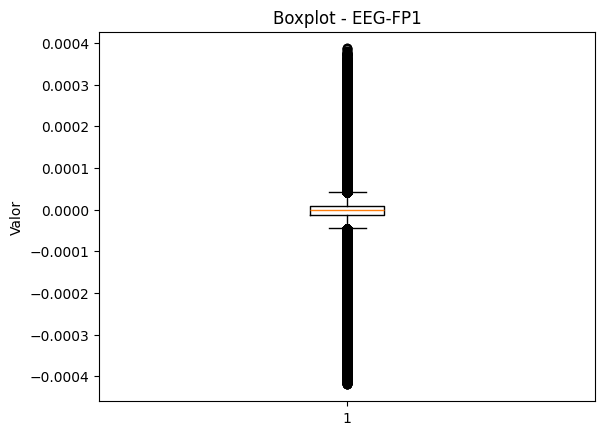

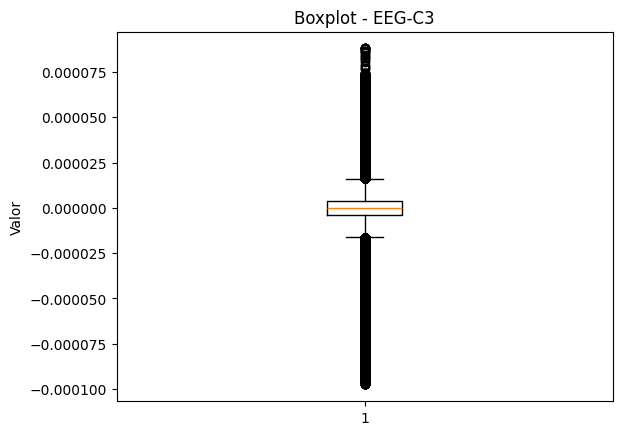

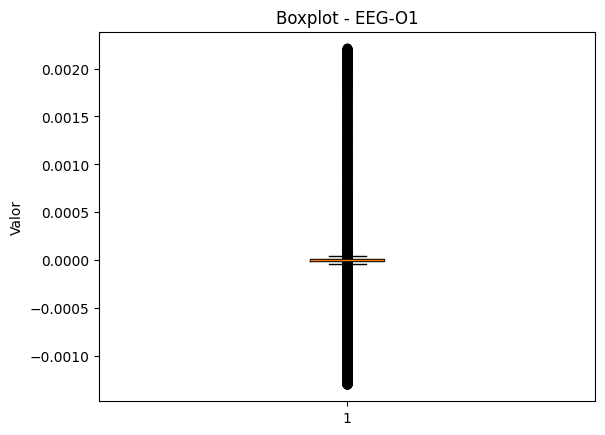

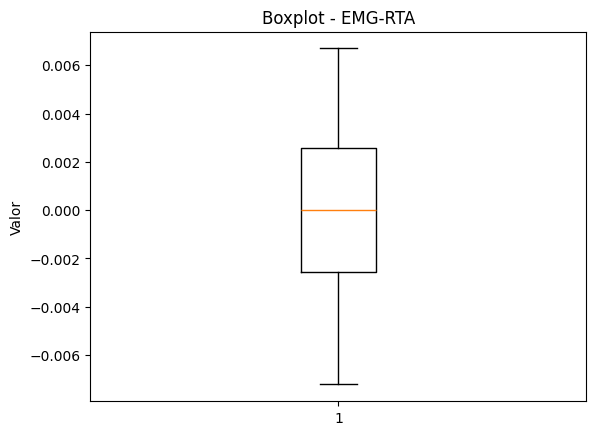

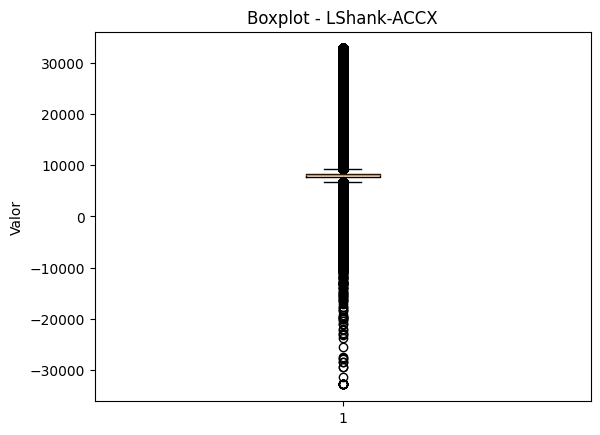

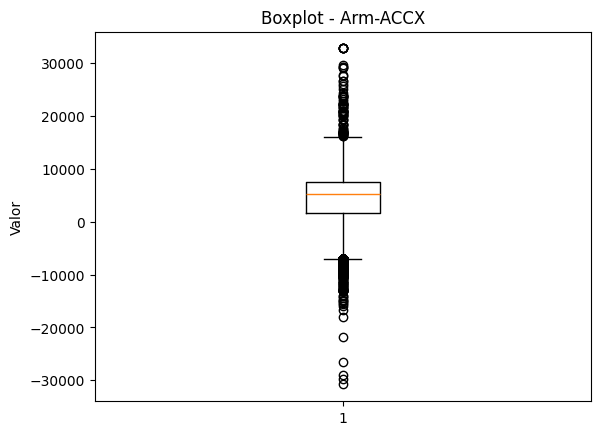

In [103]:
for col in cols_to_plot:
    if col in df.columns:
        plt.figure()
        plt.boxplot(df[col].dropna())
        plt.title(f"Boxplot - {col}")
        plt.ylabel("Valor")
        plt.show()

## 4. Visualização das Ondas (Time Series)

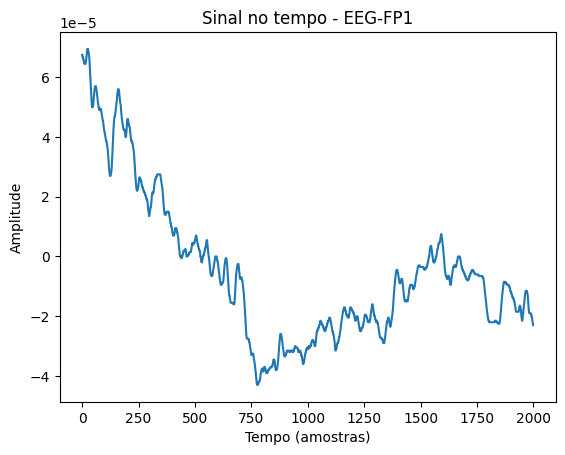

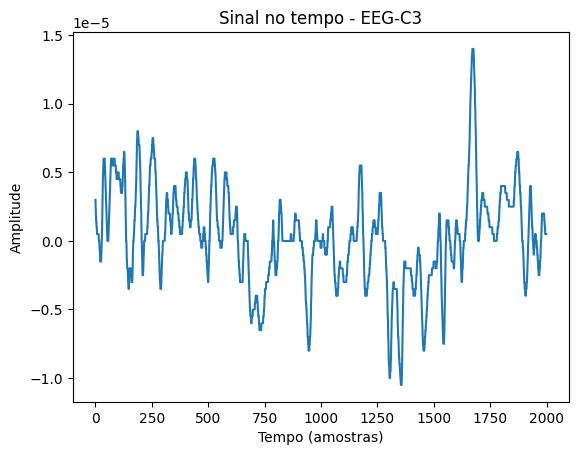

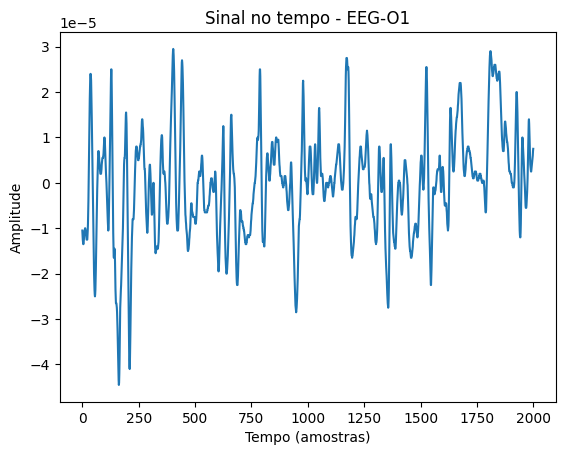

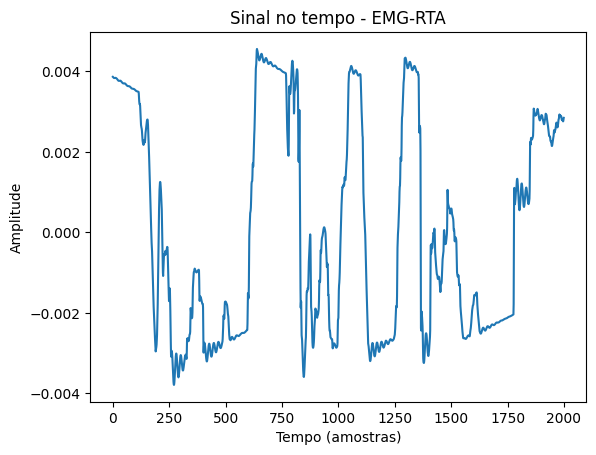

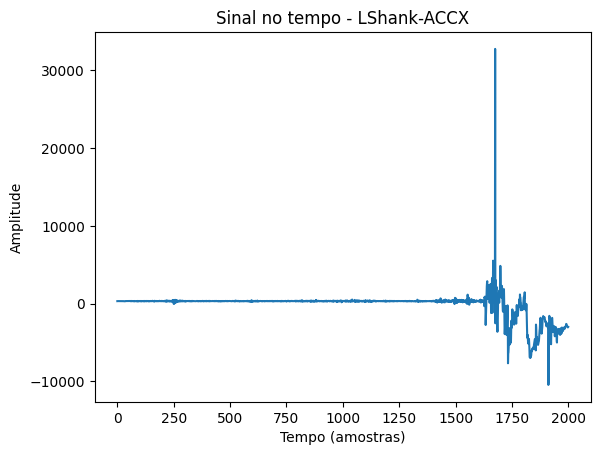

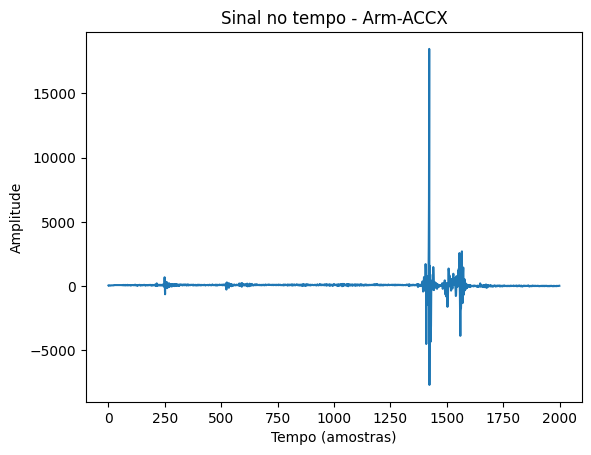

In [104]:
window = 2000  # primeiros pontos

for col in cols_to_plot:
    if col in df.columns:
        plt.figure()
        plt.plot(df[col].values[:window])
        plt.title(f"Sinal no tempo - {col}")
        plt.xlabel("Tempo (amostras)")
        plt.ylabel("Amplitude")
        plt.show()

## 5. Matriz de Correlação

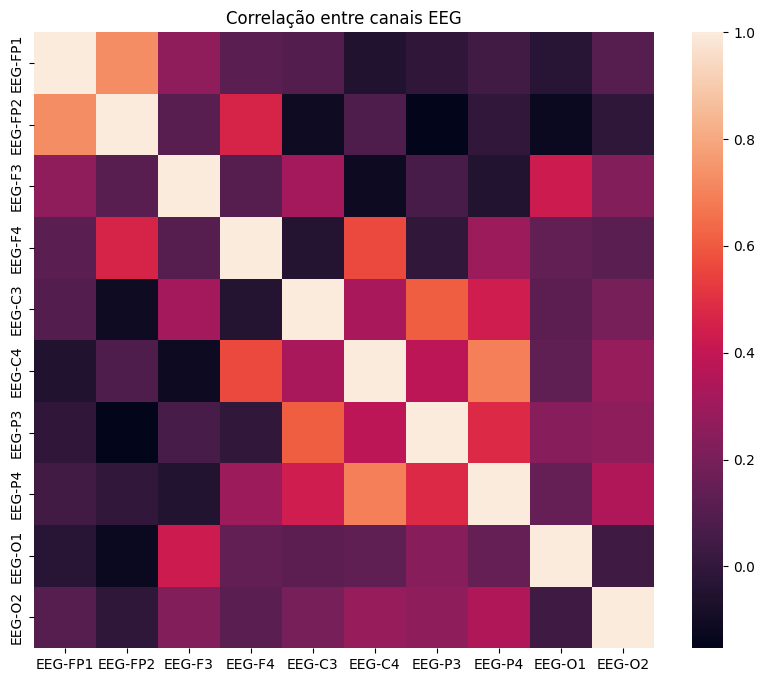

In [105]:
import seaborn as sns

corr_cols = [c for c in df.columns if "EEG" in c][:10]  # pega alguns EEG

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False)
plt.title("Correlação entre canais EEG")
plt.show()

## 6. Detecção de Sinais Mortos

In [106]:
import numpy as np

dead_channels = []

for col in df.columns:
    if df[col].dtype == "float32":
        std = np.nanstd(df[col])
        if std < 1e-6:
            dead_channels.append(col)

print("Canais possivelmente mortos:")
print(dead_channels)

/home/natan/Área de trabalho/TI093-biosignals-acquisition/venv/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Canais possivelmente mortos:
[]


## 7. Percentual de Valores Nulos

In [107]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

print(null_percent.head(20))

label            100.000000
EEG-FZ           100.000000
IO               100.000000
EEG-PZ           100.000000
EEG-CZ           100.000000
ECG               85.940345
RShank-GYRO-Z     41.980471
RShank-GYRO-Y     41.980471
RShank-NC/SC      41.980471
RShank-ACCX       41.980471
RShank-ACCY       41.980471
RShank-ACCZ       41.980471
RShank-GYRO-X     41.980471
Waist-NC/SC       36.654661
Waist-GYRO-Z      36.654661
Waist-GYRO-Y      36.654661
Waist-GYRO-X      36.654661
Waist-ACCZ        36.654661
Waist-ACCY        36.654661
Waist-ACCX        36.654661
dtype: float64


## 8. Energia do Sinal

In [108]:
energy = {}

for col in cols_to_plot:
    if col in df.columns:
        energy[col] = (df[col]**2).mean()

print("Energia média dos sinais:")
for k, v in energy.items():
    print(f"{k}: {v}")

Energia média dos sinais:
EEG-FP1: 1.4261638536794408e-09
EEG-C3: 7.000335727758156e-11
EEG-O1: 1.4495384892398988e-09
EMG-RTA: 7.109801117621828e-06
LShank-ACCX: 62336664.0
Arm-ACCX: 31905278.0


## 9. Estatísticas por Paciente

In [109]:
grouped = df.groupby("patient_id")

stats_per_patient = grouped.mean(numeric_only=True)

print(stats_per_patient.head())

                 EEG-FP1       EEG-FP2        EEG-F3        EEG-F4  \
patient_id                                                           
001         1.331365e-08  2.142076e-08  6.002334e-09  2.710659e-09   
002         3.150394e-08  1.522767e-09  9.251480e-09  9.168536e-09   
003         6.220049e-08  6.005136e-08  3.814400e-08  1.538825e-08   
004         4.605304e-08 -3.102326e-08 -7.113160e-09 -7.304567e-09   
005         5.318648e-07  1.678894e-07 -2.413347e-08  8.283343e-08   

                  EEG-C3        EEG-C4        EEG-P3        EEG-P4  \
patient_id                                                           
001        -3.978952e-10  1.426543e-08  1.617352e-08 -3.491753e-08   
002         5.667861e-09 -1.284892e-08  6.390966e-09 -1.999702e-08   
003        -5.995956e-09 -1.326494e-08 -1.241371e-08 -1.177097e-08   
004        -1.584659e-09  1.856187e-09 -5.448379e-09 -7.633962e-10   
005         5.433888e-08  1.128385e-07  5.497504e-08  7.642039e-08   

                  

## 10. Comparação entre Sensores (ACC vs GYRO)

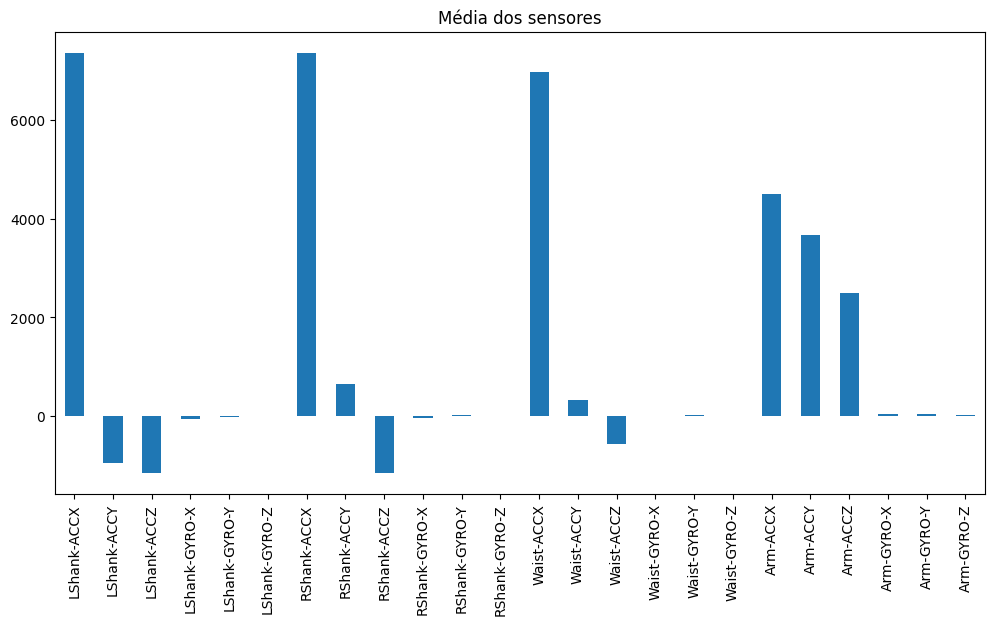

In [110]:
sensor_cols = [c for c in df.columns if "ACC" in c or "GYRO" in c]

df[sensor_cols].mean().plot(kind="bar", figsize=(12,6))
plt.title("Média dos sensores")
plt.show()

## Análise dos gráficos e estatísticas

### 1. Sinais de EEG
Os sinais de EEG representam a atividade cerebral durante as tarefas de marcha.
* **Distribuição (Histogramas e Boxplots):** Os histogramas mostram uma distribuição centrada em zero, o que é esperado para sinais AC. No entanto, os **Boxplots** revelam uma quantidade massiva de *outliers* (pontos pretos densos acima e abaixo dos bigodes). Isso indica a presença de artefatos biológicos (como piscadas de olhos no canal FP1) ou ruído de linha de 50Hz, que ainda não foram filtrados no estágio "bruto".
* **Domínio do Tempo:** O sinal de **EEG-FP1** apresenta uma derivação (drift) lenta na linha de base, característica comum de variações de impedância eletrodo-pele em dados não processados.
* **Correlação:** O mapa de calor mostra blocos de alta correlação entre canais adjacentes (ex: FP1-FP2), o que é consistente com a propagação de volume no escalpo.

### 2. Sinais de EMG (Canal EMG-RTA)
O canal **RTA** refere-se ao músculo *Tibialis anterior* da perna direita.
* **Padrão de Ativação:** O gráfico de "Sinal no tempo" mostra explosões (bursts) de amplitude que correspondem à contração muscular durante as tentativas de caminhada ou episódios de tremor.
* **Histograma Multimodal:** Diferente do EEG, o histograma do EMG apresenta picos laterais, refletindo os estados de repouso versus ativação muscular intensa.

### 3. Sinais Inerciais (Acelerômetros Arm e LShank)
Estes sensores capturam o movimento físico dos membros.
* **Aceleração no Braço (Arm-ACCX):** O histograma é visivelmente assimétrico e deslocado de zero, o que ocorre devido à componente da aceleração da gravidade ($g$) atuando sobre o eixo X, dependendo da orientação do sensor no braço.
* **Diferença de Escala:** Nos boxplots, nota-se que os valores de aceleração estão em uma escala de magnitude muito maior (até 30.000) em comparação aos sinais bioelétricos ($10^{-5}$ V), indicando que os dados de ACC são fornecidos em valores brutos de ADC (Digital-to-Analog Converter) do MPU6050.


# Conclusão

Os dados necessitam de um pré-processamento maior para poder termos uma análise estatística melhor.